# GenAI Pipeline — Batch Output

Retrieves results from an Anthropic Message Batch submitted by `genai_scope_batchinput.ipynb`,
parses the structured outputs, compares against ground-truth labels, and saves results to Excel.

### 1. Imports and Configuration

In [1]:
import duckdb
import pandas as pd
import json
import anthropic
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

DB_PATH = "../publications.db"
BATCH_DIR = Path("batch_jobs")

client = anthropic.Anthropic(api_key=os.getenv("CLAUDE_API_KEY"))

### 2. Load Batch Metadata

Set `BATCH_ID` to a specific batch ID string (e.g. `"msgbatch_01AbCdEf..."`),
or leave as `None` to pick up the most recently created batch automatically.

In [55]:
BATCH_NAME = "eval_sonnet_conf15"  # ← set to your batch name (e.g. "v12a_sonnet_test"), or None to use the most recent

if BATCH_NAME is None:
    batch_files = sorted(BATCH_DIR.glob("*.json"), key=lambda p: p.stat().st_mtime)
    if not batch_files:
        raise FileNotFoundError("No batch job files in batch_jobs/. Run genai_scope_batchinput.ipynb first.")
    metadata_path = batch_files[-1]
    print(f"Using most recent batch file: {metadata_path.name}")
else:
    metadata_path = BATCH_DIR / f"{BATCH_NAME}.json"

metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
batch_id = metadata["batch_id"]
batch_name = metadata.get("batch_name", metadata_path.stem)  # fallback for older metadata files
INCLUDE_REASONING = metadata["include_reasoning"]

print(f"Batch name: {batch_name}")
print(f"Batch ID:   {batch_id}")
print(f"Model:      {metadata['model']}")
print(f"Prompt:     {metadata['prompt_path']}")
print(f"Records:    {metadata['n_records']}")
print(f"Created:    {metadata.get('created_at', 'unknown')}")
print(f"Reasoning:  {INCLUDE_REASONING}")

Batch name: eval_sonnet_conf15
Batch ID:   msgbatch_01KvBmGqtRM1CSe7mEBLChWt
Model:      claude-sonnet-4-6
Prompt:     prompt_v12a_batch.md
Records:    2928
Created:    2026-06-17T08:08:57.590151
Reasoning:  False


### 3. Check Batch Status

Re-run this cell until `processing_status` is `ended`. The batch typically completes
well within 24 hours. Do not proceed to section 4 until it is complete.

In [56]:
batch = client.messages.batches.retrieve(batch_id)

print(f"Processing status: {batch.processing_status}")
print(f"Request counts:    {batch.request_counts}")

if batch.processing_status != "ended":
    print("\nBatch is not yet complete — re-run this cell to check again.")
else:
    print("\nBatch complete — proceed to section 4 to retrieve results.")

Processing status: ended
Request counts:    MessageBatchRequestCounts(canceled=0, errored=0, expired=0, processing=0, succeeded=2928)

Batch complete — proceed to section 4 to retrieve results.


### 4. Retrieve and Parse Results

In [57]:
if batch.processing_status != "ended":
    raise RuntimeError("Batch is not yet complete. Check status in section 3.")

raw_results = []
for result in client.messages.batches.results(batch_id):
    if result.result.type == "succeeded":
        content = result.result.message.content
        stop_reason = result.result.message.stop_reason
        tool_block = next((b for b in content if b.type == "tool_use"), None)
        if tool_block:
            record = dict(tool_block.input)
            record["id"] = result.custom_id.replace("_", ".")
            record["status"] = "ok"
            record["stop_reason"] = stop_reason
        else:
            record = {"id": result.custom_id.replace("_", "."), "status": "parse_error",
                      "error": "no tool_use block", "stop_reason": stop_reason}
    else:
        record = {
            "id": result.custom_id.replace("_", "."),
            "status": result.result.type,
            "error": str(getattr(result.result, "error", "")),
            "stop_reason": None,
        }
    raw_results.append(record)

results_df = pd.DataFrame(raw_results)

# Rename LLM output columns to add _LLM suffix (matches genai_testing.ipynb convention)
non_llm_cols = {"id", "status", "error", "stop_reason"}
results_df = results_df.rename(columns={c: f"{c}_LLM" for c in results_df.columns if c not in non_llm_cols})

print(f"Total results:  {len(results_df)}")
print(f"Successful:     {(results_df['status'] == 'ok').sum()}")
print(f"Errors:         {(results_df['status'] != 'ok').sum()}")
print(f"Missing scope:  {results_df['scope_LLM'].isna().sum()}")
print(f"\nstop_reason breakdown:\n{results_df['stop_reason'].value_counts(dropna=False)}")
results_df.head()

Total results:  2928
Successful:     2928
Errors:         0
Missing scope:  9

stop_reason breakdown:
stop_reason
tool_use    2911
refusal       17
Name: count, dtype: int64


,scope_LLM,confidence_LLM,plant_based_LLM,fermentation_LLM,cultivated_LLM,cross_cutting_LLM,id,status,stop_reason
0,in,5.0,True,False,False,False,pub.1189506115,ok,tool_use
1,out,1.0,False,False,False,False,pub.1183813532,ok,tool_use
2,out,1.0,False,False,False,False,pub.1184410252,ok,tool_use
3,out,1.0,False,False,False,False,pub.1195906710,ok,tool_use
4,out,1.0,False,False,False,False,pub.1189090576,ok,tool_use


### 5. Load Ground Truth and Compare

Merges LLM predictions against the labelled records in `publications_raw`.
Records without a ground-truth label (scope is NA) are excluded from accuracy metrics.

In [58]:
# Optional: path to an Excel file with a corrected_scope column to override raw DB ground-truth labels.
# Set to None to use the raw database values unchanged.
CORRECTIONS_PATH = Path("batch_results/msgbatch_01AdRqiFV9DQF5LT6tFXTfqZ/claude-sonnet-4-6_results.xlsx")  # e.g. Path("batch_results/my_batch/claude-sonnet-4-6_results.xlsx")

con = duckdb.connect(DB_PATH, read_only=True)
df_truth = con.sql("SELECT id, title, abstract, scope, pillar FROM publications_raw").df()
con.close()

# Filter to only the records that were in this batch
batch_ids = set(metadata["dataset_ids"])
df_truth = df_truth[df_truth["id"].isin(batch_ids)].reset_index(drop=True)

# Apply scope corrections if provided
if CORRECTIONS_PATH is not None:
    corrections = pd.read_excel(Path(CORRECTIONS_PATH), usecols=["id", "corrected_scope"])
    corrections = corrections[corrections["corrected_scope"].notna()]
    df_truth = df_truth.merge(corrections, on="id", how="left")
    mask = df_truth["corrected_scope"].notna()
    df_truth.loc[mask, "scope"] = df_truth.loc[mask, "corrected_scope"]
    df_truth = df_truth.drop(columns=["corrected_scope"])
    print(f"Scope corrections applied: {mask.sum()} records overridden from {CORRECTIONS_PATH}")
else:
    print("No corrections file set — using raw database scope values.")

result_cols = ["id", "status", "stop_reason", "scope_LLM", "confidence_LLM",
               "plant_based_LLM", "fermentation_LLM", "cultivated_LLM", "cross_cutting_LLM"]
if INCLUDE_REASONING and "reasoning_LLM" in results_df.columns:
    result_cols.insert(result_cols.index("confidence_LLM") + 1, "reasoning_LLM")

comparison = df_truth.merge(results_df[[c for c in result_cols if c in results_df.columns or c == "id"]], on="id", how="left")
comparison["correct_scope"] = comparison["scope"] == comparison["scope_LLM"]

# Coerce boolean flag columns — handles strings, ints, NaN, whitespace variants
bool_cols = ["plant_based_LLM", "fermentation_LLM", "cultivated_LLM", "cross_cutting_LLM"]
BOOL_MAP = {"true": True, "1": True, "false": False, "0": False}
for col in bool_cols:
    if col in comparison.columns:
        comparison[col] = (comparison[col].astype(str).str.lower().str.strip()
                           .map(BOOL_MAP).fillna(False))

# Derive pillar_LLM from boolean flags (same logic as genai_testing.ipynb):
# CC if multiple pillar flags are True, or if only cross_cutting_LLM is True
pillar_flags = ["plant_based_LLM", "fermentation_LLM", "cultivated_LLM"]
comparison["pillar_LLM"] = comparison[pillar_flags + ["cross_cutting_LLM"]].apply(
    lambda r: "CC" if r[pillar_flags].sum() > 1 or (r["cross_cutting_LLM"] and r[pillar_flags].sum() == 0)
              else "PB" if r["plant_based_LLM"]
              else "F"  if r["fermentation_LLM"]
              else "CM" if r["cultivated_LLM"]
              else "NA",
    axis=1
)
comparison["correct_pillar"] = comparison["pillar"] == comparison["pillar_LLM"]

comparison.head()

Scope corrections applied: 169 records overridden from batch_results\msgbatch_01AdRqiFV9DQF5LT6tFXTfqZ\claude-sonnet-4-6_results.xlsx


,id,title,abstract,scope,pillar,status,stop_reason,scope_LLM,confidence_LLM,plant_based_LLM,fermentation_LLM,cultivated_LLM,cross_cutting_LLM,correct_scope,pillar_LLM,correct_pillar
0,pub.1192791591,Mushroom: an emerging source for next generati...,"Background: In recent years, plant-based and a...",in,PB,ok,tool_use,in,5.0,True,False,False,False,True,PB,True
1,pub.1187762379,Plant-Based Alternatives to Meat Products,Animal proteins have been used in the formulat...,in,PB,ok,tool_use,in,5.0,True,False,False,False,True,PB,True
2,pub.1193391974,Influence of processing on protein quality and...,While meat is an established source of high-qu...,in,PB,ok,tool_use,in,5.0,True,False,False,False,True,PB,True
3,pub.1188899046,Solid State Fermentation—A Promising Approach ...,The increasing demand for sustainable dietary ...,in,F,ok,tool_use,in,5.0,True,False,False,False,True,PB,False
4,pub.1193352421,"Physicochemical, Microbiological and Sensory E...",The bioactive properties of a phenolic extract...,in,PB,ok,tool_use,in,5.0,True,False,False,False,True,PB,True


In [59]:
has_truth = comparison["scope"].notna() & (comparison["status"] == "ok")

print(f"Scope accuracy:  {comparison.loc[has_truth, 'correct_scope'].mean():.0%}  (n={has_truth.sum()})")
print(f"Pillar accuracy: {comparison.loc[has_truth, 'correct_pillar'].mean():.0%}  (n={has_truth.sum()})")

both_in = has_truth & (comparison["scope"] == "in") & (comparison["scope_LLM"] == "in")
print(f"Pillar accuracy — both in-scope: {comparison.loc[both_in, 'correct_pillar'].mean():.0%}  (n={both_in.sum()})")

display_cols = ["id", "title", "abstract", "scope", "scope_LLM", "confidence_LLM"]
if INCLUDE_REASONING and "reasoning_LLM" in comparison.columns:
    display_cols.append("reasoning_LLM")
display_cols += ["correct_scope", "pillar", "pillar_LLM", "correct_pillar",
                 "plant_based_LLM", "fermentation_LLM", "cultivated_LLM", "cross_cutting_LLM",
                 "status", "stop_reason"]

comparison[display_cols]

Scope accuracy:  94%  (n=2928)
Pillar accuracy: 90%  (n=2928)
Pillar accuracy — both in-scope: 89%  (n=888)


,id,title,abstract,scope,scope_LLM,confidence_LLM,correct_scope,pillar,pillar_LLM,correct_pillar,plant_based_LLM,fermentation_LLM,cultivated_LLM,cross_cutting_LLM,status,stop_reason
0,pub.1192791591,Mushroom: an emerging source for next generati...,"Background: In recent years, plant-based and a...",in,in,5.0,True,PB,PB,True,True,False,False,False,ok,tool_use
1,pub.1187762379,Plant-Based Alternatives to Meat Products,Animal proteins have been used in the formulat...,in,in,5.0,True,PB,PB,True,True,False,False,False,ok,tool_use
2,pub.1193391974,Influence of processing on protein quality and...,While meat is an established source of high-qu...,in,in,5.0,True,PB,PB,True,True,False,False,False,ok,tool_use
3,pub.1188899046,Solid State Fermentation—A Promising Approach ...,The increasing demand for sustainable dietary ...,in,in,5.0,True,F,PB,False,True,False,False,False,ok,tool_use
4,pub.1193352421,"Physicochemical, Microbiological and Sensory E...",The bioactive properties of a phenolic extract...,in,in,5.0,True,PB,PB,True,True,False,False,False,ok,tool_use
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,pub.1192217973,Mechanistic insights into Equisetum ramosissim...,Metabolic dysfunction-associated steatotic liv...,out,out,1.0,True,NA,NA,True,False,False,False,False,ok,tool_use
2924,pub.1187105909,Microbial and pest contamination in nuts: Radi...,Nuts are increasingly recognized for their ric...,out,out,1.0,True,NA,NA,True,False,False,False,False,ok,tool_use
2925,pub.1186543050,Enhancing Tomato Growth and Quality Under Defi...,This study aimed to evaluate the effect of two...,out,out,1.0,True,NA,NA,True,False,False,False,False,ok,tool_use
2926,pub.1185481528,Exploring acorn shells: Phenolic composition a...,"Pedunculate (Quercus robur L.), holm (Quercus ...",out,out,2.0,True,NA,NA,True,False,False,False,False,ok,tool_use


### 6. Save to Excel

In [60]:
save_dir = Path("batch_results") / batch_name
save_dir.mkdir(parents=True, exist_ok=True)

model_name = metadata["model"]

In [61]:

metrics_df = pd.DataFrame([
    {"metric": "scope_accuracy",                "value": f"{comparison.loc[has_truth, 'correct_scope'].mean():.0%}",               "n": int(has_truth.sum())},
    {"metric": "pillar_accuracy",               "value": f"{comparison.loc[has_truth, 'correct_pillar'].mean():.0%}",              "n": int(has_truth.sum())},
    {"metric": "pillar_accuracy_both_in_scope", "value": f"{comparison.loc[both_in, 'correct_pillar'].mean():.0%}", "n": int(both_in.sum())},
])

####################################################################################################################################
###################### NOTE THAT BATCH NAME IS USED IN THE OUTPUT FILENAME, SO DON'T SAVE IF JUST USING 'NONE' #####################
####################################################################################################################################
output_path = save_dir / f"{BATCH_NAME}_results.xlsx"
with pd.ExcelWriter(output_path) as writer:
    comparison[display_cols].to_excel(writer, sheet_name="comparison", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)

print(f"Saved to {output_path}")

Saved to batch_results\eval_sonnet_conf15\eval_sonnet_conf15_results.xlsx


In [62]:
missing_cols = ["id", "status", "stop_reason", "scope_LLM"]
if "error" in results_df.columns:
    missing_cols.insert(3, "error")

missing_scope = results_df.loc[results_df["scope_LLM"].isna(), missing_cols].merge(
    comparison[["id", "title", "abstract"]], on="id", how="left"
)
missing_scope = missing_scope[["id", "title", "abstract"] + [c for c in missing_cols if c != "id"]]

print(f"Records with missing scope_LLM: {len(missing_scope)}")

if len(missing_scope) > 0:
    missing_path = save_dir / f"{model_name}_missing_scope.xlsx"
    missing_scope.to_excel(missing_path, index=False)
    print(f"Saved to {missing_path}")

missing_scope

Records with missing scope_LLM: 9
Saved to batch_results\eval_sonnet_conf15\claude-sonnet-4-6_missing_scope.xlsx


,id,title,abstract,status,stop_reason,scope_LLM
0,pub.1194203543,External factors influence intrinsic differenc...,Porcine Shiga toxin-producing Escherichia coli...,ok,refusal,NaN
1,pub.1194299948,Omics Insights into Cylindrospermopsin’s Molec...,Cylindrospermopsin (CYN) is a potent cyanotoxi...,ok,refusal,NaN
2,pub.1187286037,Cucumber green mottle mosaic virus encodes add...,The vast majority of known viruses belong to t...,ok,refusal,NaN
3,pub.1187661745,Biotechnology-enhanced immunoassay for accurat...,Consumption of edible insects is common in non...,ok,refusal,NaN
4,pub.1195743879,Do Food Preservatives Affect Staphylococcal En...,"Staphylococcal enterotoxins (SEs), particularl...",ok,refusal,NaN
5,pub.1186079543,Press Forward: Advancing Vaccine Production Wi...,Introduction Viral inactivation constitutes th...,ok,refusal,NaN
6,pub.1196486262,Defence-mediated phloem restriction of a plant...,Plant viruses are causal agents of devastating...,ok,refusal,NaN
7,pub.1195080979,Efficacy of genetically modified Mycoplasma hy...,Vaccination against Mycoplasma hyopneumoniae i...,ok,refusal,NaN
8,pub.1188507802,Advances in African swine fever virus molecula...,African swine fever virus (ASFV) causes a freq...,ok,refusal,NaN


### 7. Comprehensive Evaluation Metrics

All metrics computed on records with a ground-truth label **and** a successful LLM response with a non-null confidence score. The `% of total` and bucket-size plot denominator is all batch records (including errors).

In [63]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

def safe_div(a, b):
    return a / b if b > 0 else float("nan")

# Working set: ground truth + successful LLM response + non-null confidence
df_eval = comparison[has_truth & comparison["confidence_LLM"].notna()].copy()
df_eval["conf"] = df_eval["confidence_LLM"].astype(int)

TP = int(((df_eval["scope"] == "in") & (df_eval["scope_LLM"] == "in")).sum())
FP = int(((df_eval["scope"] == "out") & (df_eval["scope_LLM"] == "in")).sum())
TN = int(((df_eval["scope"] == "out") & (df_eval["scope_LLM"] == "out")).sum())
FN = int(((df_eval["scope"] == "in") & (df_eval["scope_LLM"] == "out")).sum())
N  = TP + FP + TN + FN

overall_metrics = pd.DataFrame({
    "metric":  ["Accuracy", "Sensitivity (Recall)", "Precision", "NPV", "Specificity"],
    "value":   [safe_div(TP+TN, N), safe_div(TP, TP+FN),
                safe_div(TP, TP+FP), safe_div(TN, TN+FN), safe_div(TN, TN+FP)],
    "n":       [N, TP+FN, TP+FP, TN+FN, TN+FP],
})

print(f"TP={TP}  FP={FP}  TN={TN}  FN={FN}  N={N}\n")
fmt = overall_metrics.copy()
fmt["value"] = fmt["value"].map(lambda x: f"{x:.1%}" if not np.isnan(x) else "—")
display(fmt[["metric", "value", "n"]])

TP=888  FP=20  TN=1854  FN=156  N=2918



,metric,value,n
0,Accuracy,94.0%,2918
1,Sensitivity (Recall),85.1%,1044
2,Precision,97.8%,908
3,NPV,92.2%,2010
4,Specificity,98.9%,1874


In [64]:
def bucket_metrics(sub, total_n, total_in):
    tp = int(((sub["scope"] == "in") & (sub["scope_LLM"] == "in")).sum())
    fp = int(((sub["scope"] == "out") & (sub["scope_LLM"] == "in")).sum())
    tn = int(((sub["scope"] == "out") & (sub["scope_LLM"] == "out")).sum())
    fn = int(((sub["scope"] == "in") & (sub["scope_LLM"] == "out")).sum())
    return {
        "N":           len(sub),
        "Precision":   safe_div(tp, tp + fp),
        "NPV":         safe_div(tn, tn + fn),
        "Sensitivity": safe_div(tp, total_in),  # coverage: fraction of all true-in captured in this bucket
        "% of total":  len(sub) / total_n,
    }

total_in   = int((df_eval["scope"] == "in").sum())
max_conf   = int(df_eval["conf"].max())
conf_scale = 7 if max_conf > 5 else 5

if conf_scale == 5:
    buckets = [
        ("Confidence = 1",   df_eval[df_eval["conf"] == 1]),
        ("Confidence = 2",   df_eval[df_eval["conf"] == 2]),
        ("Confidence = 3",   df_eval[df_eval["conf"] == 3]),
        ("Confidence = 4",   df_eval[df_eval["conf"] == 4]),
        ("Confidence = 5",   df_eval[df_eval["conf"] == 5]),
        ("Confidence 1+2",   df_eval[df_eval["conf"].isin([1, 2])]),
        ("Confidence 4+5",   df_eval[df_eval["conf"].isin([4, 5])]),
        ("Confidence 2+3+4", df_eval[df_eval["conf"].isin([2, 3, 4])]),
        ("Confidence 2+3",   df_eval[df_eval["conf"].isin([2, 3])]),
        ("Confidence 1+4+5",   df_eval[df_eval["conf"].isin([1, 4, 5])])
    ]
else:
    buckets = [
        ("Confidence = 1",     df_eval[df_eval["conf"] == 1]),
        ("Confidence = 2",     df_eval[df_eval["conf"] == 2]),
        ("Confidence = 3",     df_eval[df_eval["conf"] == 3]),
        ("Confidence = 4",     df_eval[df_eval["conf"] == 4]),
        ("Confidence = 5",     df_eval[df_eval["conf"] == 5]),
        ("Confidence = 6",     df_eval[df_eval["conf"] == 6]),
        ("Confidence = 7",     df_eval[df_eval["conf"] == 7]),
        ("Confidence 1+2+3",   df_eval[df_eval["conf"].isin([1, 2, 3])]),
        ("Confidence 5+6+7",   df_eval[df_eval["conf"].isin([5, 6, 7])]),
        ("Confidence 3+4+5",   df_eval[df_eval["conf"].isin([3, 4, 5])]),
        ("Confidence 3+4",     df_eval[df_eval["conf"].isin([3, 4])]),
        ("Confidence 2+3+4",   df_eval[df_eval["conf"].isin([2, 3, 4])]),
        ("Confidence 1+5+6+7", df_eval[df_eval["conf"].isin([1, 5, 6, 7])]),
    ]

print(f"Detected confidence scale: 1–{conf_scale}\n")

conf_table = pd.DataFrame([
    {"Confidence bucket": label, **bucket_metrics(sub, len(comparison), total_in)}
    for label, sub in buckets
])

fmt = conf_table.copy()
for col in ["Precision", "NPV", "Sensitivity", "% of total"]:
    fmt[col] = fmt[col].map(lambda x: f"{x:.1%}" if isinstance(x, float) and not np.isnan(x) else "—")
display(fmt)

Detected confidence scale: 1–5



,Confidence bucket,N,Precision,NPV,Sensitivity,% of total
0,Confidence = 1,1098,—,99.4%,0.0%,37.5%
1,Confidence = 2,896,100.0%,83.3%,0.2%,30.6%
2,Confidence = 3,73,82.2%,—,5.7%,2.5%
3,Confidence = 4,311,97.7%,—,29.1%,10.6%
4,Confidence = 5,540,100.0%,100.0%,50.0%,18.4%
5,Confidence 1+2,1994,100.0%,92.2%,0.2%,68.1%
6,Confidence 4+5,851,99.2%,100.0%,79.1%,29.1%
7,Confidence 2+3+4,1280,94.8%,83.3%,35.1%,43.7%
8,Confidence 2+3,969,82.7%,83.3%,5.9%,33.1%
9,Confidence 1+4+5,1949,99.2%,99.4%,79.1%,66.6%


In [65]:
with pd.ExcelWriter(output_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    overall_metrics.to_excel(writer, sheet_name="overall_metrics", index=False)
    conf_table.to_excel(writer, sheet_name="confidence_buckets", index=False)

print(f"Saved 'overall_metrics' and 'confidence_buckets' sheets to:\n  {output_path}")

Saved 'overall_metrics' and 'confidence_buckets' sheets to:
  batch_results\eval_sonnet_conf15\eval_sonnet_conf15_results.xlsx


In [66]:
# Bucket definitions — 1-5: excl=1, manual=2–3, incl=4–5
#                     1-7: excl=1, manual=2–4, incl=5–7
_excl_vals = [1]
_man_vals  = [2, 3]     if conf_scale == 5 else [2, 3, 4]
_incl_vals = [4, 5]     if conf_scale == 5 else [5, 6, 7]

excl_sub = df_eval[df_eval["conf"].isin(_excl_vals)]
man_sub  = df_eval[df_eval["conf"].isin(_man_vals)]
incl_sub = df_eval[df_eval["conf"].isin(_incl_vals)]

total_n   = len(comparison)
total_in  = int((df_eval["scope"] == "in").sum())
total_out = int((df_eval["scope"] == "out").sum())

# Auto-include metrics
incl_tp  = int(((incl_sub["scope"] == "in")  & (incl_sub["scope_LLM"] == "in")).sum())
incl_fp  = int(((incl_sub["scope"] == "out") & (incl_sub["scope_LLM"] == "in")).sum())
incl_precision = safe_div(incl_tp, incl_tp + incl_fp)
incl_contam    = safe_div(incl_fp, total_out)  # FP ÷ total truly out-of-scope
incl_dilution  = safe_div(incl_fp, total_in)   # FP ÷ total truly in-scope pool

# Auto-exclude metrics
excl_tn  = int(((excl_sub["scope"] == "out") & (excl_sub["scope_LLM"] == "out")).sum())
excl_fn  = int(((excl_sub["scope"] == "in")  & (excl_sub["scope_LLM"] == "out")).sum())
excl_npv  = safe_div(excl_tn, excl_tn + excl_fn)
excl_loss = safe_div(excl_fn, total_in)         # FN ÷ total truly in-scope

# Manual review
man_in  = int((man_sub["scope"] == "in").sum())
man_out = int((man_sub["scope"] == "out").sum())

excl_label = f"Auto-exclude (conf={_excl_vals[0]})"
man_label  = f"Manual review (conf={_man_vals[0]}–{_man_vals[-1]})"
incl_label = f"Auto-include (conf={_incl_vals[0]}–{_incl_vals[-1]})"

bucket_summary = pd.DataFrame([
    {
        "Bucket":                                             excl_label,
        "N":                                                  len(excl_sub),
        "% of total":                                         len(excl_sub) / total_n,
        "NPV":                                                excl_npv,
        "Loss rate (% truly in-scope lost)":                  excl_loss,
        "N truly in-scope in bucket":                         excl_fn,
        "N truly out-of-scope in bucket":                     excl_tn,
        "Precision":                                          float("nan"),
        "Contamination rate (% truly out-of-scope included)": float("nan"),
        "Dilution rate (FP ÷ total true in-scope pool)":      float("nan"),
        "% truly in-scope within bucket":                     float("nan"),
        "% truly out-of-scope within bucket":                 float("nan"),
    },
    {
        "Bucket":                                             man_label,
        "N":                                                  len(man_sub),
        "% of total":                                         len(man_sub) / total_n,
        "N truly in-scope in bucket":                         man_in,
        "N truly out-of-scope in bucket":                     man_out,
        "% truly in-scope within bucket":                     safe_div(man_in,  man_in + man_out),
        "% truly out-of-scope within bucket":                 safe_div(man_out, man_in + man_out),
        "NPV":                                                float("nan"),
        "Loss rate (% truly in-scope lost)":                  float("nan"),
        "Precision":                                          float("nan"),
        "Contamination rate (% truly out-of-scope included)": float("nan"),
        "Dilution rate (FP ÷ total true in-scope pool)":      float("nan"),
    },
    {
        "Bucket":                                             incl_label,
        "N":                                                  len(incl_sub),
        "% of total":                                         len(incl_sub) / total_n,
        "Precision":                                          incl_precision,
        "Contamination rate (% truly out-of-scope included)": incl_contam,
        "Dilution rate (FP ÷ total true in-scope pool)":      incl_dilution,
        "N truly in-scope in bucket":                         incl_tp,
        "N truly out-of-scope in bucket":                     incl_fp,
        "NPV":                                                float("nan"),
        "Loss rate (% truly in-scope lost)":                  float("nan"),
        "% truly in-scope within bucket":                     float("nan"),
        "% truly out-of-scope within bucket":                 float("nan"),
    },
])

# Formatted display
fmt = bucket_summary.copy()
pct_cols = ["% of total", "NPV", "Loss rate (% truly in-scope lost)", "Precision",
            "Contamination rate (% truly out-of-scope included)",
            "Dilution rate (FP ÷ total true in-scope pool)",
            "% truly in-scope within bucket", "% truly out-of-scope within bucket"]
for col in pct_cols:
    fmt[col] = fmt[col].map(lambda x: f"{x:.1%}" if isinstance(x, float) and not np.isnan(x) else "—")
display(fmt)

with pd.ExcelWriter(output_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    bucket_summary.to_excel(writer, sheet_name="bucket_summary", index=False)

print(f"\nSaved 'bucket_summary' sheet to {output_path}")

,Bucket,N,% of total,NPV,Loss rate (% truly in-scope lost),N truly in-scope in bucket,N truly out-of-scope in bucket,Precision,Contamination rate (% truly out-of-scope included),Dilution rate (FP ÷ total true in-scope pool),% truly in-scope within bucket,% truly out-of-scope within bucket
0,Auto-exclude (conf=1),1098,37.5%,99.4%,0.7%,7,1091,—,—,—,—,—
1,Manual review (conf=2–3),969,33.1%,—,—,211,758,—,—,—,21.8%,78.2%
2,Auto-include (conf=4–5),851,29.1%,—,—,826,7,99.2%,0.4%,0.7%,—,—



Saved 'bucket_summary' sheet to batch_results\eval_sonnet_conf15\eval_sonnet_conf15_results.xlsx


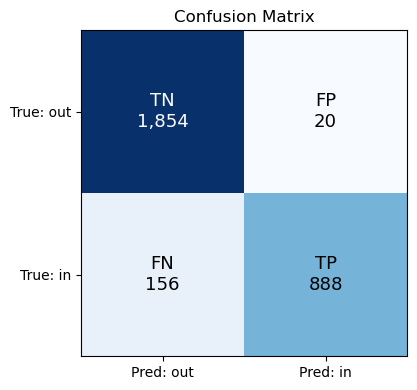

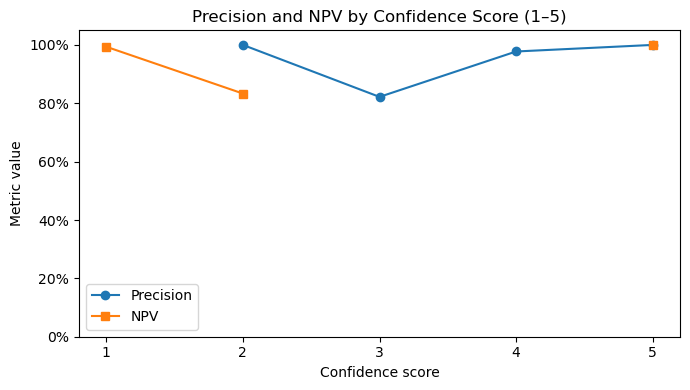

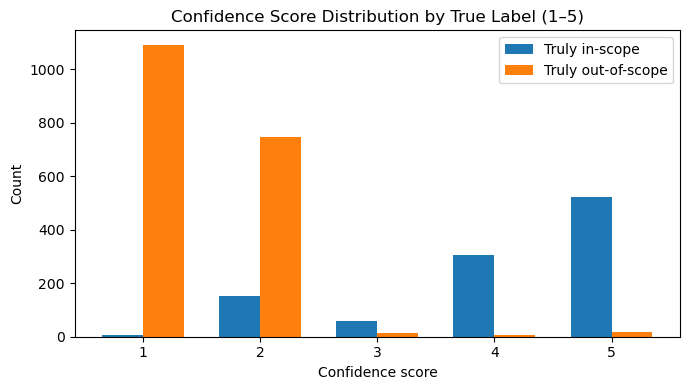

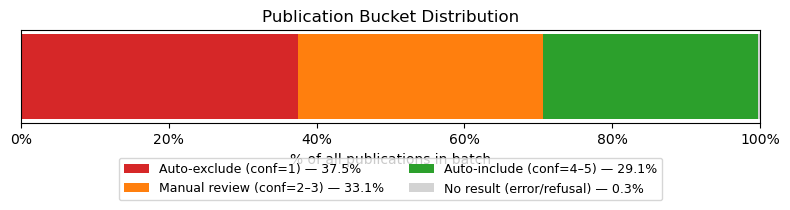

All 4 plots saved to batch_results\eval_sonnet_conf15


In [67]:
fig_dir        = save_dir
conf_levels    = list(range(1, conf_scale + 1))          # [1..5] or [1..7]
auto_excl_vals = [1]
manual_vals    = [2, 3] if conf_scale == 5 else [2, 3, 4]
auto_incl_vals = [4, 5] if conf_scale == 5 else [5, 6, 7]

# ── 1. Confusion matrix ────────────────────────────────────────────────────
cm_arr = np.array([[TN, FP], [FN, TP]])
cell_labels = [["TN", "FP"], ["FN", "TP"]]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_arr, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred: out", "Pred: in"])
ax.set_yticklabels(["True: out", "True: in"])
thresh = cm_arr.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cell_labels[i][j]}\n{cm_arr[i,j]:,}",
                ha="center", va="center", fontsize=13,
                color="white" if cm_arr[i, j] > thresh else "black")
ax.set_title("Confusion Matrix")
plt.tight_layout()
fig.savefig(fig_dir / "plot_confusion_matrix.png", dpi=150)
plt.show()

# ── 2. Precision and NPV vs confidence score ───────────────────────────────
prec_vals, npv_vals = [], []
for c in conf_levels:
    s = df_eval[df_eval["conf"] == c]
    tp_c = int(((s["scope"] == "in") & (s["scope_LLM"] == "in")).sum())
    fp_c = int(((s["scope"] == "out") & (s["scope_LLM"] == "in")).sum())
    tn_c = int(((s["scope"] == "out") & (s["scope_LLM"] == "out")).sum())
    fn_c = int(((s["scope"] == "in") & (s["scope_LLM"] == "out")).sum())
    prec_vals.append(safe_div(tp_c, tp_c + fp_c))
    npv_vals.append(safe_div(tn_c, tn_c + fn_c))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(conf_levels, prec_vals, marker="o", label="Precision", color="tab:blue")
ax.plot(conf_levels, npv_vals,  marker="s", label="NPV",       color="tab:orange")
ax.set_xticks(conf_levels)
ax.set_xlabel("Confidence score")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
ax.set_title(f"Precision and NPV by Confidence Score (1–{conf_scale})")
plt.tight_layout()
fig.savefig(fig_dir / "plot_precision_npv_by_confidence.png", dpi=150)
plt.show()

# ── 3. Confidence distribution by true label ───────────────────────────────
dist = (df_eval.groupby(["conf", "scope"]).size()
        .unstack(fill_value=0)
        .reindex(conf_levels, fill_value=0))
for col in ["in", "out"]:
    if col not in dist.columns:
        dist[col] = 0

x = np.arange(len(conf_levels))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, dist["in"].values,  width, label="Truly in-scope",     color="tab:blue")
ax.bar(x + width/2, dist["out"].values, width, label="Truly out-of-scope", color="tab:orange")
ax.set_xticks(x); ax.set_xticklabels(conf_levels)
ax.set_xlabel("Confidence score")
ax.set_ylabel("Count")
ax.set_title(f"Confidence Score Distribution by True Label (1–{conf_scale})")
ax.legend()
plt.tight_layout()
fig.savefig(fig_dir / "plot_confidence_distribution.png", dpi=150)
plt.show()

# ── 4. Bucket size stacked bar ─────────────────────────────────────────────
n_tot  = len(comparison)
p_excl = len(df_eval[df_eval["conf"].isin(auto_excl_vals)]) / n_tot
p_man  = len(df_eval[df_eval["conf"].isin(manual_vals)])    / n_tot
p_incl = len(df_eval[df_eval["conf"].isin(auto_incl_vals)]) / n_tot
p_miss = (n_tot - len(df_eval)) / n_tot

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.barh(0, p_excl,                           color="tab:red",    label=f"Auto-exclude (conf={auto_excl_vals[0]}) — {p_excl:.1%}")
ax.barh(0, p_man,  left=p_excl,              color="tab:orange", label=f"Manual review (conf={manual_vals[0]}–{manual_vals[-1]}) — {p_man:.1%}")
ax.barh(0, p_incl, left=p_excl+p_man,        color="tab:green",  label=f"Auto-include (conf={auto_incl_vals[0]}–{auto_incl_vals[-1]}) — {p_incl:.1%}")
ax.barh(0, p_miss, left=p_excl+p_man+p_incl, color="lightgrey",  label=f"No result (error/refusal) — {p_miss:.1%}")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_yticks([])
ax.set_xlabel("% of all publications in batch")
ax.set_title("Publication Bucket Distribution")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2, fontsize=9)
plt.tight_layout()
fig.savefig(fig_dir / "plot_bucket_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"All 4 plots saved to {fig_dir}")

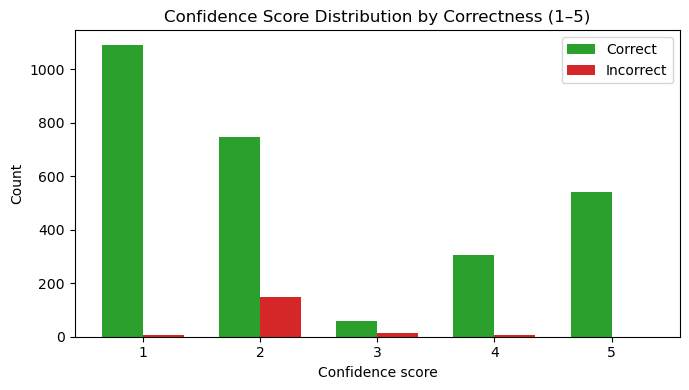

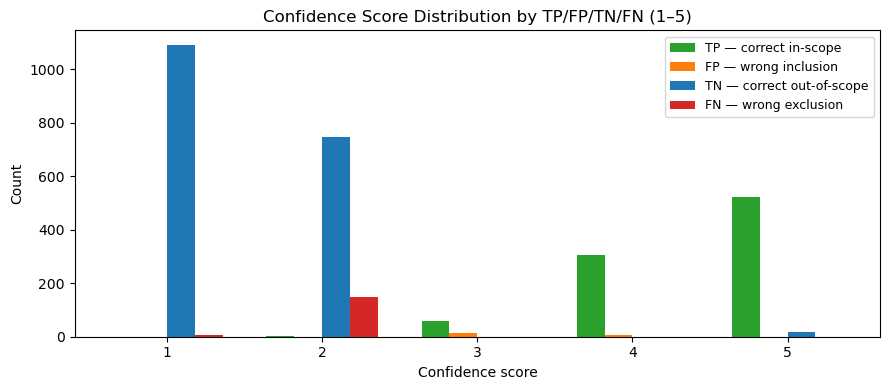

Plots saved to batch_results\eval_sonnet_conf15


In [68]:
# ── 5. Confidence distribution by correct / incorrect ─────────────────────
dist_corr = (df_eval.assign(correct=df_eval["scope"] == df_eval["scope_LLM"])
             .groupby(["conf", "correct"]).size()
             .unstack(fill_value=0)
             .reindex(conf_levels, fill_value=0))
for col in [True, False]:
    if col not in dist_corr.columns:
        dist_corr[col] = 0

x = np.arange(len(conf_levels))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, dist_corr[True].values,  width, label="Correct",   color="tab:green")
ax.bar(x + width/2, dist_corr[False].values, width, label="Incorrect", color="tab:red")
ax.set_xticks(x); ax.set_xticklabels(conf_levels)
ax.set_xlabel("Confidence score")
ax.set_ylabel("Count")
ax.set_title(f"Confidence Score Distribution by Correctness (1–{conf_scale})")
ax.legend()
plt.tight_layout()
fig.savefig(fig_dir / "plot_confidence_by_correctness.png", dpi=150)
plt.show()

# ── 6. Confidence distribution by TP / FP / TN / FN ──────────────────────
conditions = [
    (df_eval["scope"] == "in")  & (df_eval["scope_LLM"] == "in"),
    (df_eval["scope"] == "out") & (df_eval["scope_LLM"] == "in"),
    (df_eval["scope"] == "out") & (df_eval["scope_LLM"] == "out"),
    (df_eval["scope"] == "in")  & (df_eval["scope_LLM"] == "out"),
]
df_eval = df_eval.copy()
df_eval["cm_cell"] = np.select(conditions, ["TP", "FP", "TN", "FN"], default="unknown")

dist_cm = (df_eval.groupby(["conf", "cm_cell"]).size()
           .unstack(fill_value=0)
           .reindex(conf_levels, fill_value=0))
for col in ["TP", "FP", "TN", "FN"]:
    if col not in dist_cm.columns:
        dist_cm[col] = 0

width = 0.18
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 1.5*width, dist_cm["TP"].values, width, label="TP — correct in-scope",    color="tab:green")
ax.bar(x - 0.5*width, dist_cm["FP"].values, width, label="FP — wrong inclusion",     color="tab:orange")
ax.bar(x + 0.5*width, dist_cm["TN"].values, width, label="TN — correct out-of-scope", color="tab:blue")
ax.bar(x + 1.5*width, dist_cm["FN"].values, width, label="FN — wrong exclusion",     color="tab:red")
ax.set_xticks(x); ax.set_xticklabels(conf_levels)
ax.set_xlabel("Confidence score")
ax.set_ylabel("Count")
ax.set_title(f"Confidence Score Distribution by TP/FP/TN/FN (1–{conf_scale})")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(fig_dir / "plot_confidence_by_cm_cell.png", dpi=150)
plt.show()

print(f"Plots saved to {fig_dir}")

#### Protein Label Analysis

Per-label Precision, Recall, and F1 calculated twice: (1) all truly in-scope publications, (2) TPs in the auto-include bucket only (truly in-scope, correctly classified as in-scope, within the auto-include confidence range). Each label is treated as an independent binary classification.

In [69]:
def pillar_label_metrics(eval_df):
    rows = []
    for pillar_val in ["PB", "F", "CM", "CC"]:
        tp = int(((eval_df["pillar"] == pillar_val) & (eval_df["pillar_LLM"] == pillar_val)).sum())
        fp = int(((eval_df["pillar"] != pillar_val) & (eval_df["pillar_LLM"] == pillar_val)).sum())
        fn = int(((eval_df["pillar"] == pillar_val) & (eval_df["pillar_LLM"] != pillar_val)).sum())
        precision = safe_div(tp, tp + fp)
        recall    = safe_div(tp, tp + fn)
        if np.isnan(precision) or np.isnan(recall):
            f1 = float("nan")
        elif (precision + recall) == 0:
            f1 = 0.0
        else:
            f1 = 2 * precision * recall / (precision + recall)
        rows.append({
            "Pillar":    pillar_val,
            "N (true)":  int((eval_df["pillar"] == pillar_val).sum()),
            "TP":        tp,
            "FP":        fp,
            "FN":        fn,
            "Precision": precision,
            "Recall":    recall,
            "F1":        f1,
        })
    return pd.DataFrame(rows)

def display_label_df(df, title):
    print(f"\n{title} (n={df['N (true)'].sum()}):")
    fmt = df.copy()
    for col in ["Precision", "Recall", "F1"]:
        fmt[col] = fmt[col].map(lambda x: f"{x:.1%}" if isinstance(x, float) and not np.isnan(x) else "—")
    display(fmt)

# Subset 1: all truly in-scope with a ground-truth pillar label
all_in_scope = df_eval[(df_eval["scope"] == "in") & df_eval["pillar"].notna()].copy()
label_df_all = pillar_label_metrics(all_in_scope)
display_label_df(label_df_all, "All truly in-scope")

# Subset 2: TPs in auto-include bucket — truly in-scope, correctly classified, in auto-include confidence range
# Excludes pillar=="NA" (in-scope records without a ground-truth label) for a clean comparison
incl_tp_eval = df_eval[
    (df_eval["scope"] == "in") &
    (df_eval["scope_LLM"] == "in") &
    df_eval["conf"].isin(_incl_vals) &
    df_eval["pillar"].notna() &
    (df_eval["pillar"] != "NA")
].copy()
label_df_incl = pillar_label_metrics(incl_tp_eval)
display_label_df(label_df_incl, f"TPs in auto-include bucket (conf={_incl_vals[0]}–{_incl_vals[-1]})")

with pd.ExcelWriter(output_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    label_df_all.to_excel(writer, sheet_name="label_all_in_scope", index=False)
    label_df_incl.to_excel(writer, sheet_name="label_auto_incl_TPs", index=False)

print(f"\nSaved 'label_all_in_scope' and 'label_auto_incl_TPs' to {output_path}")


All truly in-scope (n=1014):


,Pillar,N (true),TP,FP,FN,Precision,Recall,F1
0,PB,673,520,20,153,96.3%,77.3%,85.7%
1,F,149,125,18,24,87.4%,83.9%,85.6%
2,CM,96,73,5,23,93.6%,76.0%,83.9%
3,CC,96,70,57,26,55.1%,72.9%,62.8%



TPs in auto-include bucket (conf=4–5) (n=804):


,Pillar,N (true),TP,FP,FN,Precision,Recall,F1
0,PB,527,494,10,33,98.0%,93.7%,95.8%
1,F,124,115,4,9,96.6%,92.7%,94.7%
2,CM,85,71,2,14,97.3%,83.5%,89.9%
3,CC,68,61,47,7,56.5%,89.7%,69.3%



Saved 'label_all_in_scope' and 'label_auto_incl_TPs' to batch_results\eval_sonnet_conf15\eval_sonnet_conf15_results.xlsx


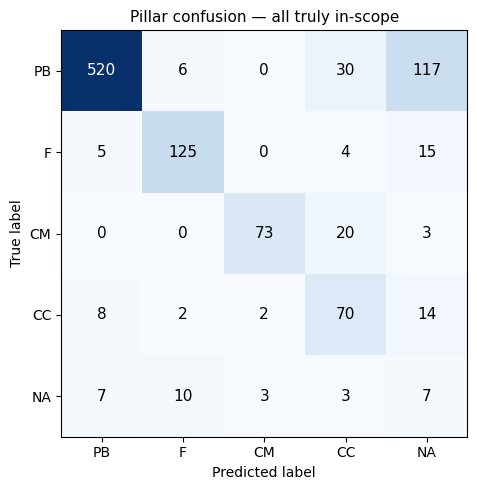

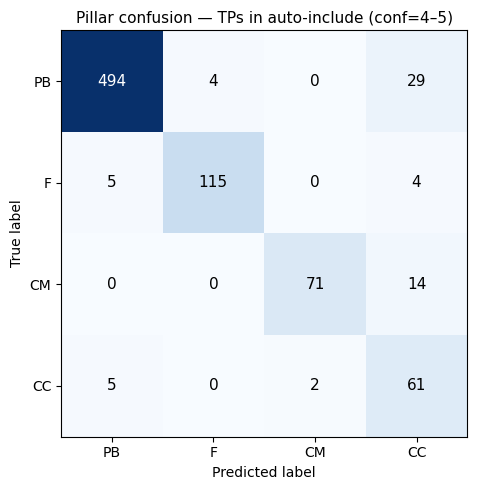

Saved plots to batch_results\eval_sonnet_conf15
Saved confusion matrices to batch_results\eval_sonnet_conf15\eval_sonnet_conf15_results.xlsx


In [70]:
def plot_pillar_cm(ax, eval_df, title):
    labels_order = ["PB", "F", "CM", "CC", "NA"]
    row_labels = [l for l in labels_order if l in eval_df["pillar"].values]
    col_labels = [l for l in labels_order if l in eval_df["pillar_LLM"].values]

    cm = pd.crosstab(
        eval_df["pillar"], eval_df["pillar_LLM"],
        rownames=["True label"], colnames=["Predicted label"]
    ).reindex(index=row_labels, columns=col_labels, fill_value=0)

    im = ax.imshow(cm.values, cmap="Blues")
    ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels)
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title, fontsize=11)
    thresh = cm.values.max() / 2
    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            ax.text(j, i, str(cm.values[i, j]), ha="center", va="center",
                    color="white" if cm.values[i, j] > thresh else "black", fontsize=11)
    return cm

# Plot 1 — all truly in-scope (NA true-label row present: in-scope pubs without a pillar assignment)
fig, ax = plt.subplots(figsize=(7, 5))
cm_all = plot_pillar_cm(ax, all_in_scope, "Pillar confusion — all truly in-scope")
plt.tight_layout()
fig.savefig(fig_dir / "plot_pillar_confusion_all.png", dpi=150)
plt.show()

# Plot 2 — TPs in auto-include only (NA excluded from both true and predicted labels)
fig, ax = plt.subplots(figsize=(7, 5))
cm_incl = plot_pillar_cm(ax, incl_tp_eval,
                         f"Pillar confusion — TPs in auto-include (conf={_incl_vals[0]}–{_incl_vals[-1]})")
plt.tight_layout()
fig.savefig(fig_dir / "plot_pillar_confusion_auto_incl.png", dpi=150)
plt.show()

with pd.ExcelWriter(output_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    cm_all.to_excel(writer, sheet_name="pillar_cm_all_in_scope")
    cm_incl.to_excel(writer, sheet_name="pillar_cm_auto_incl_TPs")

print(f"Saved plots to {fig_dir}")
print(f"Saved confusion matrices to {output_path}")

In [71]:
def get_raw_flag_pattern(row):
    pb = bool(row["plant_based_LLM"])
    f  = bool(row["fermentation_LLM"])
    cm = bool(row["cultivated_LLM"])
    cc = bool(row["cross_cutting_LLM"])
    n  = int(pb) + int(f) + int(cm)

    if n == 0 and not cc:  return "NA"
    if n == 0 and cc:      return "CC only"
    if n == 1 and not cc:
        if pb: return "PB only"
        if f:  return "F only"
        return "CM only"
    if n == 1 and cc:
        if pb: return "PB + CC"
        if f:  return "F + CC"
        return "CM + CC"
    if n == 2 and not cc:
        if not cm: return "PB + F"
        if not f:  return "PB + CM"
        return "F + CM"
    if n == 3 and not cc:  return "PB + F + CM"
    return "Other"

pred_cats = [
    "PB only", "F only", "CM only",
    "PB + CC", "F + CC", "CM + CC", "CC only",
    "PB + F", "PB + CM", "F + CM", "PB + F + CM",
    "NA", "Other",
]
true_labels = ["PB", "F", "CM", "CC"]

fn_records = incl_tp_eval[incl_tp_eval["pillar"] != incl_tp_eval["pillar_LLM"]].copy()
fn_records["pred_pattern"] = fn_records.apply(get_raw_flag_pattern, axis=1)

count_rows = []
pct_rows   = []
for true_label in true_labels:
    true_sub   = incl_tp_eval[incl_tp_eval["pillar"] == true_label]
    fn_sub     = fn_records[fn_records["pillar"] == true_label]
    n_true     = len(true_sub)
    n_fn       = len(fn_sub)
    cat_counts = fn_sub["pred_pattern"].value_counts()

    count_row = {"True label": true_label, "N (true)": n_true, "FN (total)": n_fn}
    for cat in pred_cats:
        count_row[cat] = int(cat_counts.get(cat, 0))
    count_rows.append(count_row)

    pct_row = {"True label": f"{true_label} (% of FN)", "N (true)": "—", "FN (total)": "100%" if n_fn > 0 else "—"}
    for cat in pred_cats:
        cnt = int(cat_counts.get(cat, 0))
        pct_row[cat] = f"{cnt / n_fn:.1%}" if n_fn > 0 and cnt > 0 else "—"
    pct_rows.append(pct_row)

fn_breakdown = pd.DataFrame(count_rows + pct_rows)

cat_nonzero = [c for c in pred_cats
               if any(fn_breakdown.loc[fn_breakdown["True label"].isin(true_labels), c] != 0)]
display_cols_fb = ["True label", "N (true)", "FN (total)"] + cat_nonzero
display(fn_breakdown[display_cols_fb])

with pd.ExcelWriter(output_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    fn_breakdown[display_cols_fb].to_excel(writer, sheet_name="pillar_FN_breakdown", index=False)

print(f"\nSaved 'pillar_FN_breakdown' to {output_path}")

,True label,N (true),FN (total),PB only,F only,CM only,PB + CC,CM + CC,CC only,PB + F,PB + CM,F + CM,PB + F + CM,Other
0,PB,527,33,0,4,0,0,0,23,5,0,0,1,0
1,F,124,9,5,0,0,0,0,0,2,0,1,0,1
2,CM,85,14,0,0,0,0,0,12,0,1,1,0,0
3,CC,68,7,3,0,1,2,1,0,0,0,0,0,0
4,PB (% of FN),—,100%,—,12.1%,—,—,—,69.7%,15.2%,—,—,3.0%,—
5,F (% of FN),—,100%,55.6%,—,—,—,—,—,22.2%,—,11.1%,—,11.1%
6,CM (% of FN),—,100%,—,—,—,—,—,85.7%,—,7.1%,7.1%,—,—
7,CC (% of FN),—,100%,42.9%,—,14.3%,28.6%,14.3%,—,—,—,—,—,—



Saved 'pillar_FN_breakdown' to batch_results\eval_sonnet_conf15\eval_sonnet_conf15_results.xlsx
